# Lesson 4: Cleaning float time series 🧹

### 🎯 Learning Objectives
In this lesson, we will learn how to download the float time series and individual profiles identified using the filtered Argo index file (Lesson 1) and figures (Lesson 2).

### 🛠️ Prerequisites
Before starting this lesson, make sure that you have completed **Lesson 3**.
If you are using **Binder**, make sure to upload the relevant index files created in **Lesson 1**.

### ❓ How to Use This Notebook
* 📚 **Read** the tutorial text blocks carefully, as they provide the essential background information behind the code.
* ▶️ **Run** each code cell sequentially by clicking the cell and pressing `Shift + Enter`.
* 📝 **Exercise** your knowledge! At the end of this notebook, we provide active learning exercises where you will need to write or modify the code yourself.

### Ready? Let's Get Started!
---

## 📚 Tutorial

### Import libraries

▶️ **Run** the cell below to import relevant Python libraries for this lesson.

In [27]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

### Define the WMO ID of the float of your interest

In [3]:
wmoid = 5906513

### Load the filtered index file

▶️ **Run** the cell below to load the float time series downloaded in Lesson 3.

In [5]:
in_file = f"{wmoid}/{wmoid}_Sprof.nc"
ds = xr.open_dataset(in_file) 
ds

<xarray.Dataset> Size: 19MB
Dimensions:                           (N_PROF: 123, N_PARAM: 9, N_CALIB: 1,
                                       N_LEVELS: 554)
Dimensions without coordinates: N_PROF, N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/93)
    DATA_TYPE                         object 8B ...
    FORMAT_VERSION                    object 8B ...
    HANDBOOK_VERSION                  object 8B ...
    REFERENCE_DATE_TIME               object 8B ...
    DATE_CREATION                     object 8B ...
    DATE_UPDATE                       object 8B ...
    ...                                ...
    NITRATE                           (N_PROF, N_LEVELS) float32 273kB ...
    NITRATE_QC                        (N_PROF, N_LEVELS) object 545kB ...
    NITRATE_dPRES                     (N_PROF, N_LEVELS) float32 273kB ...
    NITRATE_ADJUSTED                  (N_PROF, N_LEVELS) float32 273kB ...
    NITRATE_ADJUSTED_QC               (N_PROF, N_LEVELS) object 545kB ...
    NITRATE_ADJUSTED_ERROR            (N_PROF, N_LEVELS) float32 273kB ...
Attributes:
    title:                Argo float vertical profile
    institution:          AOML
    source:               Argo float
    history:              2026-03-26T01:30:55Z creation (software version 1.2...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.20 (version 12.05.2025 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

### Dimensions

We see from the output above that there are multiple dimensions. The relevant ones are **N_PROF** and **N_LEVELS**:

* **N_PROF** tells you how many profiles are in the data.
* **N_LEVELS** tells you the maximum number of depth levels in the data. Note that each profile has different sampling depths, and therefore the number of samples.

### Data variables

Next, click on **Data variables** above to see the list of available variables in the data. There are so many! But we only use a few of these.

The following variables are 1D arrays (N_PROF) containing each profile's sampling date and location:

* **JULD**: date and time
* **LATITUDE**: latitude
* **LONGITUDE**: longitude

The following variables are 2D arrays (N_PROF x N_LEVELS) containing each profile's physical oceanoraphic data:

* **PRES_ADJUSTED**: adjusted pressure (dbar)
* **TEMP_ADJUSTED**: adjusted temperature (deg-c)
* **TEMP_ADJUSTED_QC**: quality-control flag for adjusted temperature (-)
* **PSAL_ADJUSTED**: adjusted salinity (psu)
* **PSAL_ADJUSTED_QC**: quality-control flag for adjusted salinity (-)

Note that we will use adjusted values (e.g., **PRES_ADJUSTED**) instead of raw values (e.g., **PRES**) because the adjusted values are always better.

Quality-control (QC) flags (i.e., **\*_ADJUSTED_QC** in our case) refer to the quality of the data values. A standard practice is to only use data with QC flags of 1, 2, 5, or 8. [The Argo Online School](https://euroargodev.github.io/argoonlineschool/Lessons/L02_TheArgoData/Chapter24_QualityFlagMean.html) provides a nice summary of QC flags for Argo, including what each flag means.

The description for the biogeochemical variables (2D arrays) is omitted here because it was already provided in Lesson 1 (see **Filter by BGC parameters**). Similar to pressure, temperature, and salinity, we will use adjusted values (**\*_ADJUSTED**) and corresponding QC flags (**\*_ADJUSTED_QC**).

We will not consider **PRES_ADJUSTED_QC** because some floats do not provide values.

### Define the function `filter_qc`

▶️ **Run** the cell below to define a function that filters the adjusted values by QC flags

In [25]:
def filter_qc(ds_in, name_in, qc_in):
    """
    This function filters the data based on their QC flags.

    INPUT:
    * ds_in: xarray dataset of the float time series
    * name_in: name of the variable (string)
    * qc_in: list of the accepted QC flags (list)

    OUTPUT:
    * data_out: QC-filtered adjusted values
    """    
    data = ds_in[f"{name_in}_ADJUSTED"]
    qc = ds_in[f"{name_in}_ADJUSTED_QC"] 
    valid = qc.astype(str).isin([str(x) for x in qc_in])
    data_valid = data.where(valid, other=np.nan)
    
    return data_valid

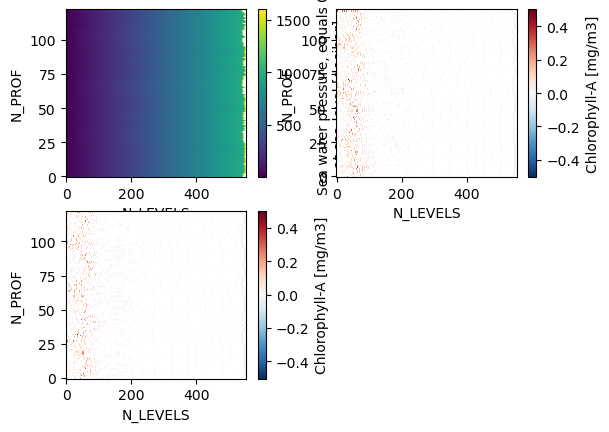

In [35]:
plt.subplot(221)
pres_filtered = filter_qc(ds, "PRES", [1,2,5,8])
pres_filtered.plot()
plt.subplot(222)
chla_filtered = filter_qc(ds, "CHLA", [1,2,5,8])
chla_filtered.plot()
plt.subplot(223)
chla_filtered.where(pres_filtered.notnull(), other=np.nan).plot()

### Sampling time and cycle

In [95]:
def time_and_dt(ds_in):
    wmoid = str(ds["PLATFORM_NUMBER"].astype(int).values[0])

    # sampling time
    plt.figure()
    utc_hours = ds_in["JULD"].dt.hour + (ds_in["JULD"].dt.minute / 60) + (ds_in["JULD"].dt.second / 3600)
    utc_hours.plot(marker="|",ls="None")
    plt.title(f"WMO ID = {wmoid}")
    plt.ylim(0,24)
    plt.ylabel('UTC (hours)')
    plt.tight_layout()
    plt.savefig(f'{wmoid}/sampling_time_{wmoid}.png', dpi=300, bbox_inches='tight')
    
    # sampling cycle
    plt.figure()
    dt_cycle = ds_in["JULD"].diff(dim='N_PROF') / np.timedelta64(1, 'D')
    dt_cycle.plot(marker="|",ls="None")
    plt.title(f"WMO ID = {wmoid}")
    plt.ylabel(r'$\Delta$t (days)')
    plt.tight_layout()
    plt.savefig(f'{wmoid}/sampling_cycle_{wmoid}.png', dpi=300, bbox_inches='tight')
    
    return utc_hours, dt_cycle

▶️ **Run** the cell below to use the function to calculate and visualize the sampling time and cycle

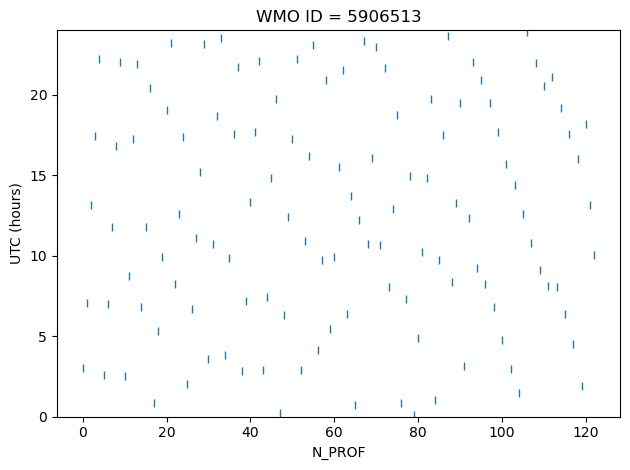

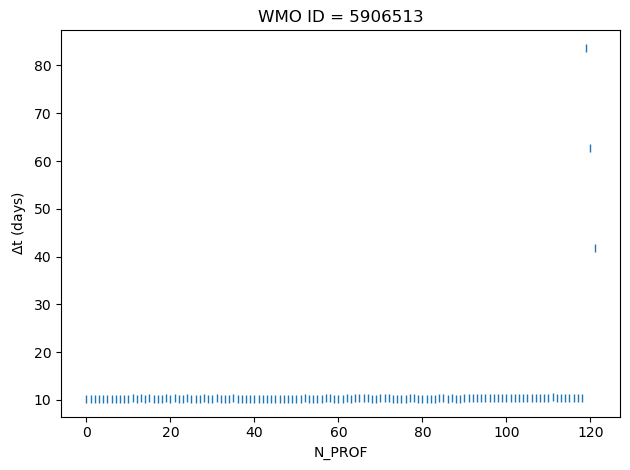

In [79]:
utc_hours, dt_cycle = time_and_dt(ds)

### Visualize raw data

▶️ **Run** the cell below to

In [96]:
def plot_raw(ds):

    # standard variable names
    vars_original = ['PRES_ADJUSTED',
                     'TEMP_ADJUSTED',
                     'PSAL_ADJUSTED',
                     'DOWNWELLING_PAR_ADJUSTED',
                     'NITRATE_ADJUSTED',
                     'CHLA_ADJUSTED',
                     'BBP700_ADJUSTED',
                     'DOXY_ADJUSTED',
                     'PH_IN_SITU_TOTAL_ADJUSTED',
                    ]
        
    for j in range(len(vars_original)): # loop over variables
        try:
            vars_original[j] in ds.data_vars
            if ds[vars_original[j]].notnull().any(): # if finite values exit
                plt.figure()
                mmin,mmax = ds[vars_original[j]].min().astype(float).values,ds[vars_original[j]].max().astype(float).values
                ds[vars_original[j]].plot(x="N_PROF",vmin=mmin,vmax=mmax)
                plt.title(f"min: {mmin}, max: {mmax}")            
                plt.gca().invert_yaxis()
                plt.tight_layout()
            else:
              print('NO VALID DATA for '+vars_original[j])  
        except:
            print('NO DATA for '+vars_original[j])

Run the cell below

NO DATA for DOWNWELLING_PAR_ADJUSTED


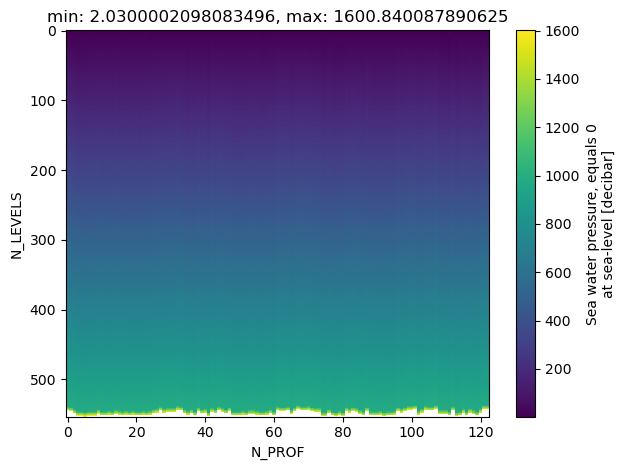

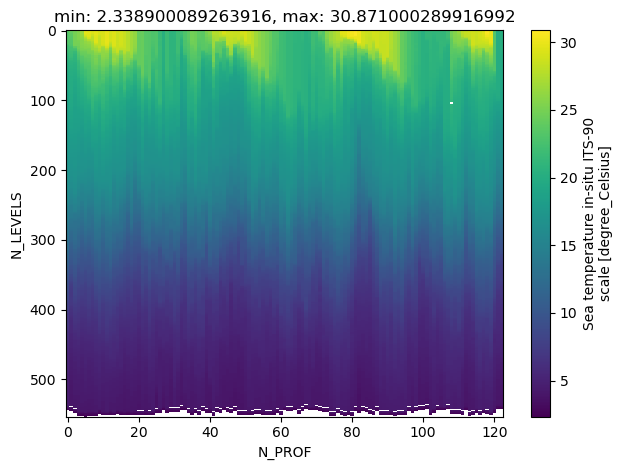

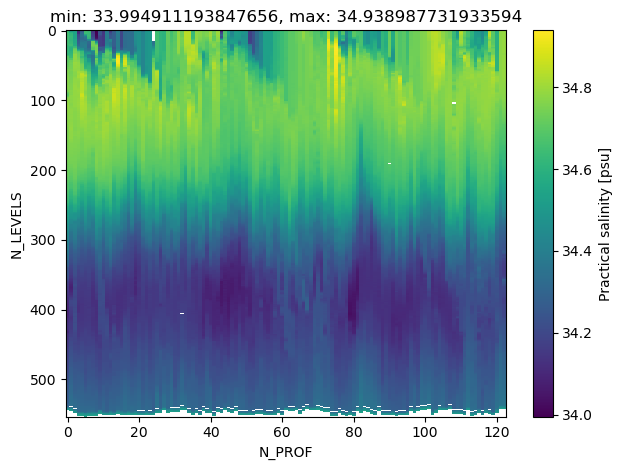

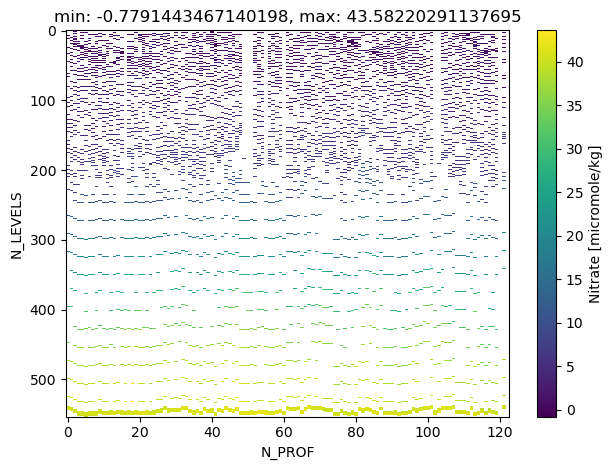

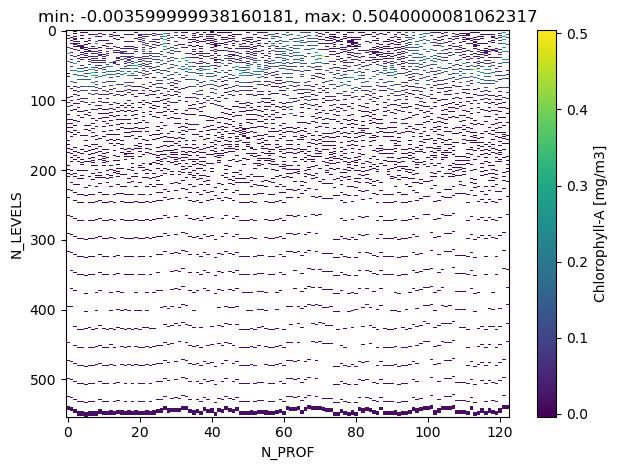

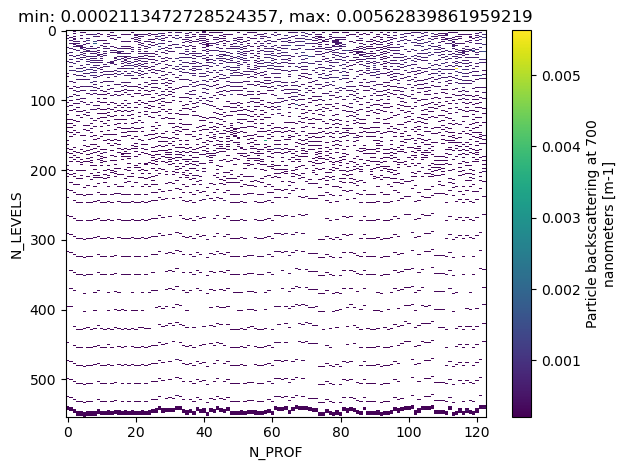

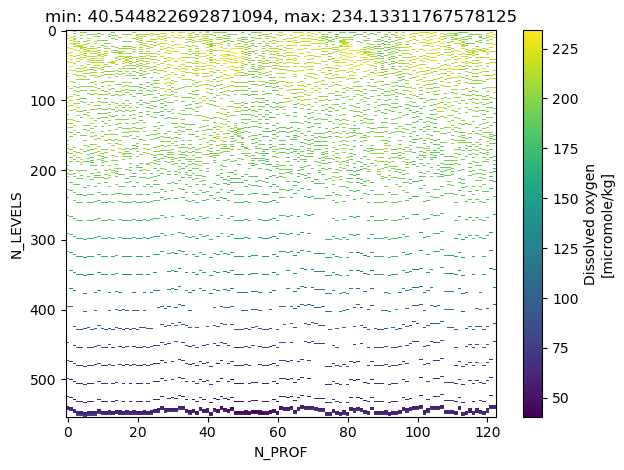

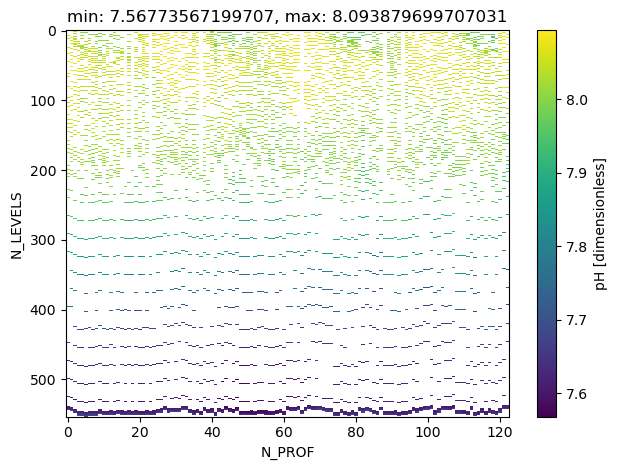

In [93]:
plot_raw(ds)

**This is the end of the tutorials for Lesson 3. Hope you enjoyed it!**

---

## 📝 Exercises

Using the filtered index files created in Lesson 1 and the figures created in Lesson 2, identify and download the float time series or individual profiles that meet specific criteria using the function `download_argo`.

### Exercise 1: Visualize the float time series downloaded in Ex 2 of Lesson 3.

5905531

NO VALID DATA for DOWNWELLING_PAR_ADJUSTED


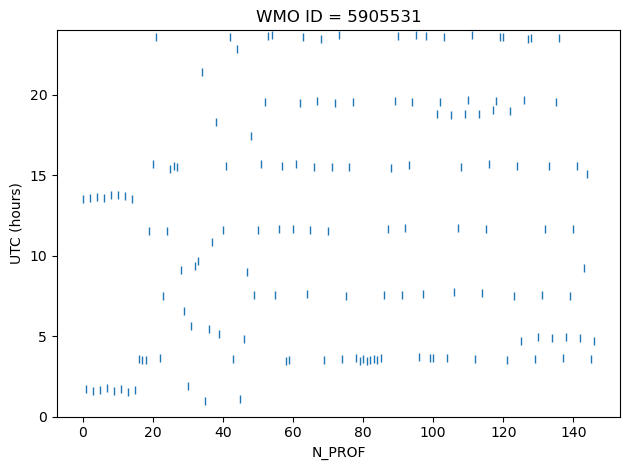

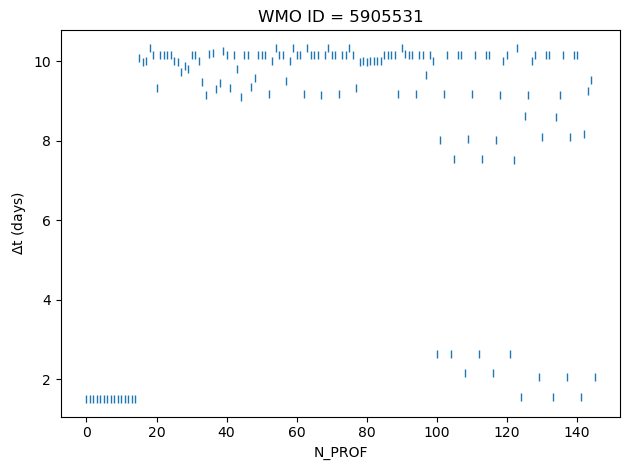

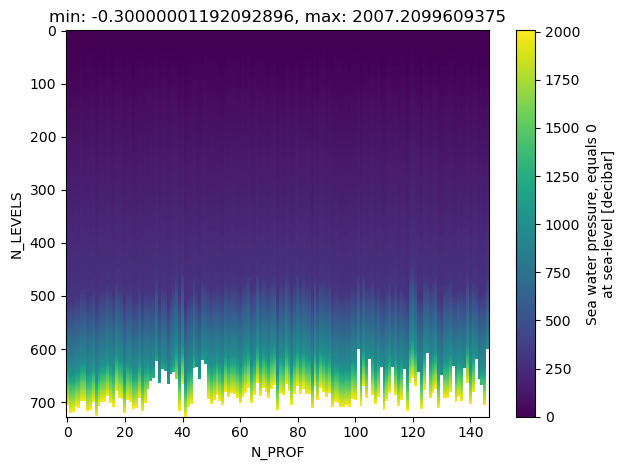

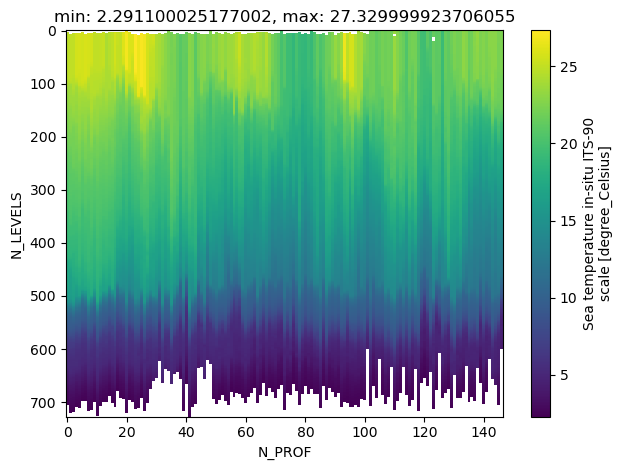

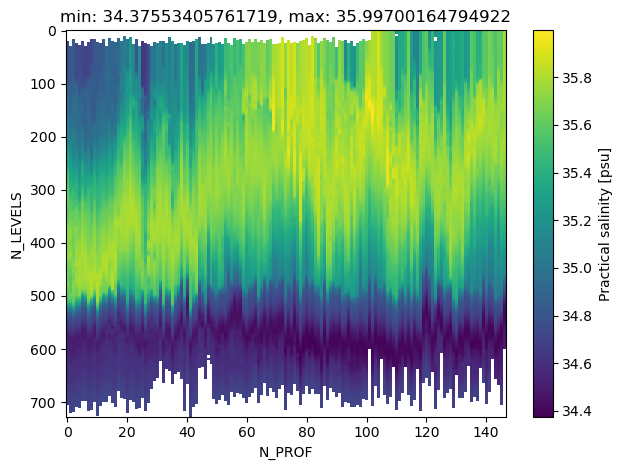

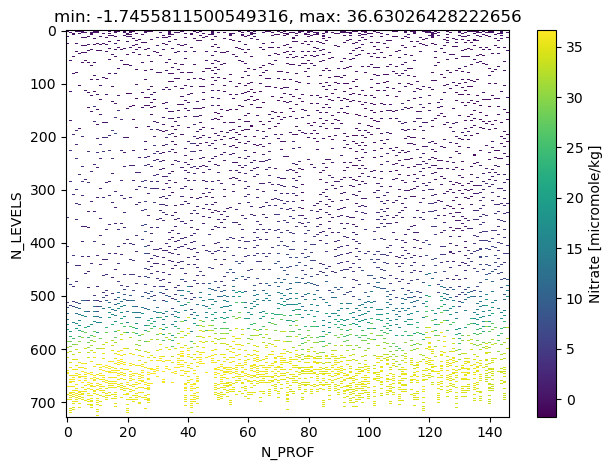

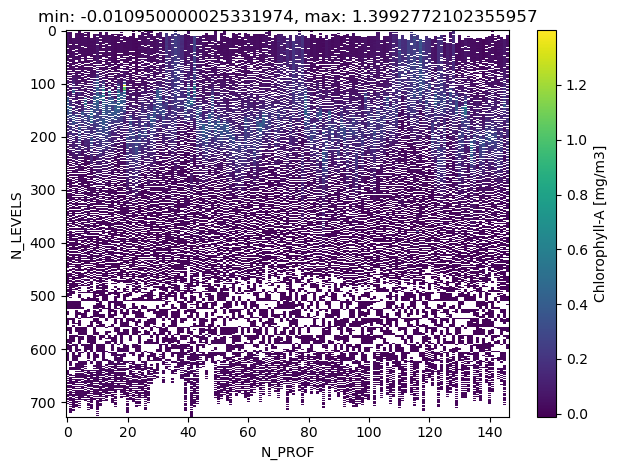

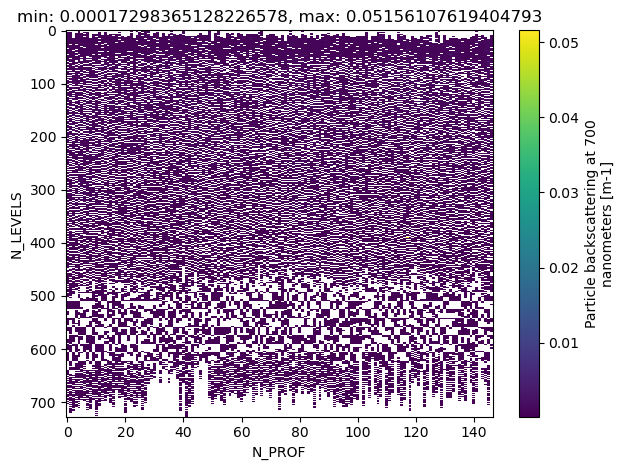

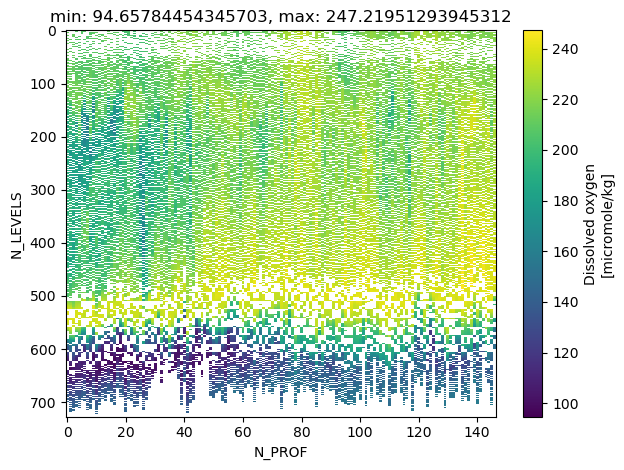

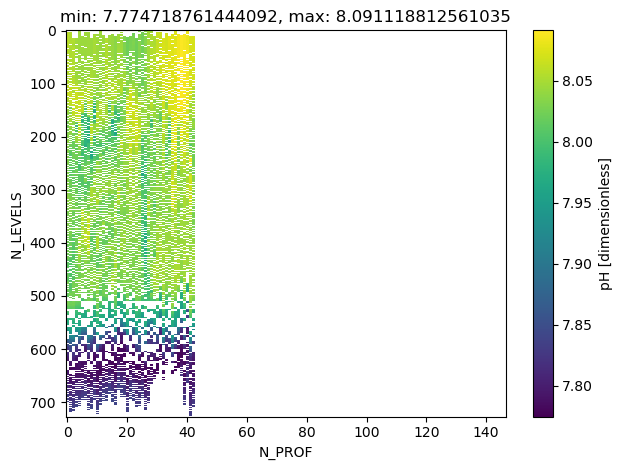

In [97]:
wmoid = 5905531
in_file = f"{wmoid}/{wmoid}_Sprof.nc"
ds = xr.open_dataset(in_file) 

time_and_dt(ds)

plot_raw(ds)

### Exercise 2:

5906475, 

NO DATA for DOWNWELLING_PAR_ADJUSTED


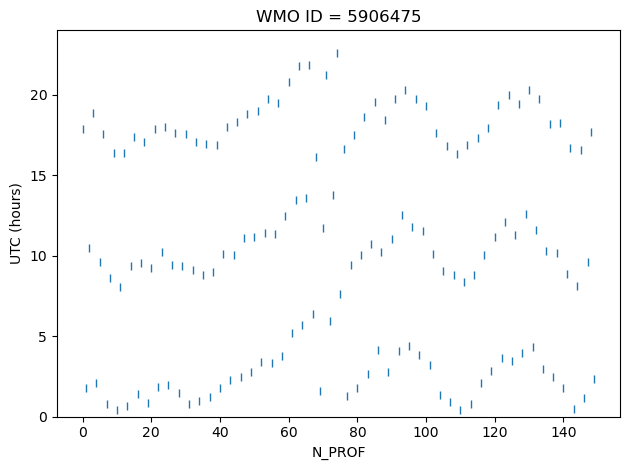

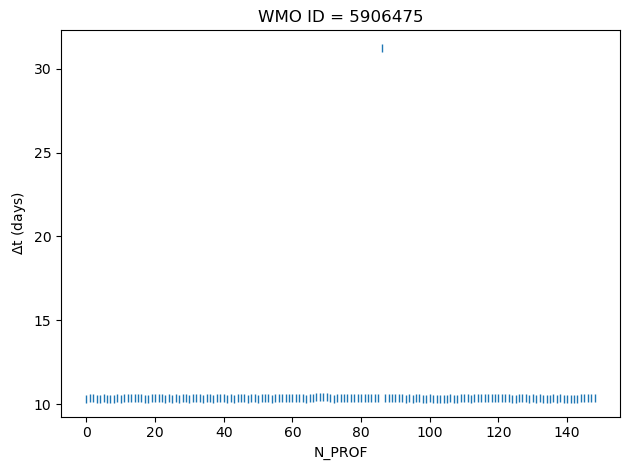

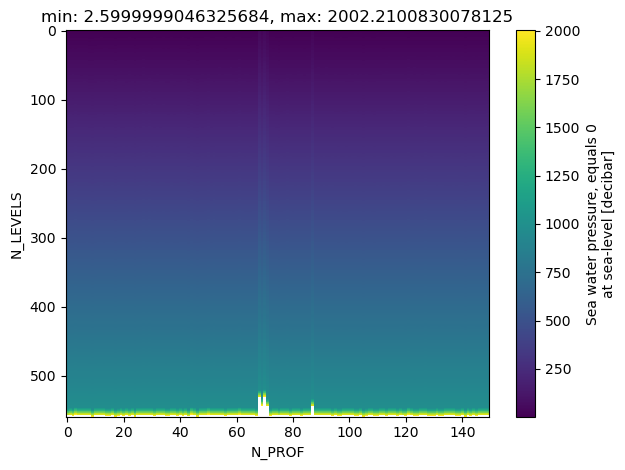

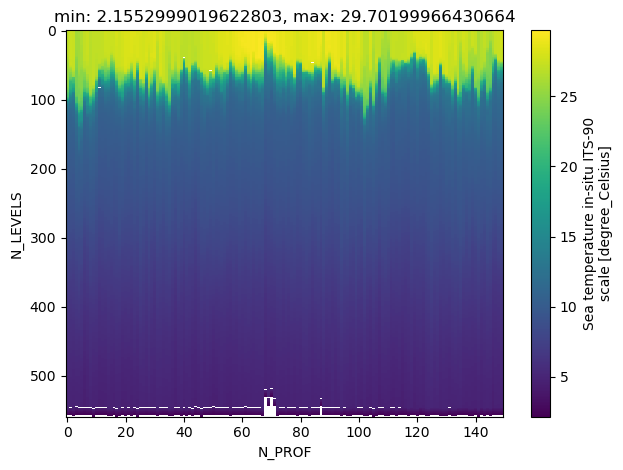

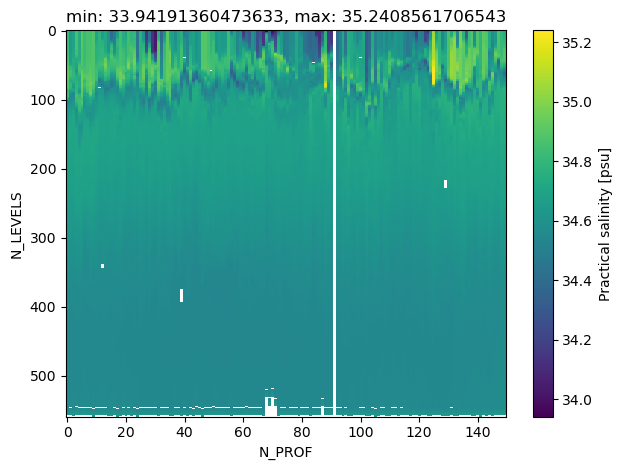

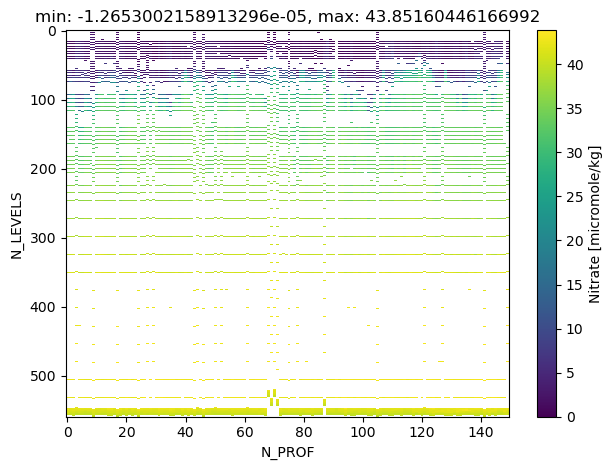

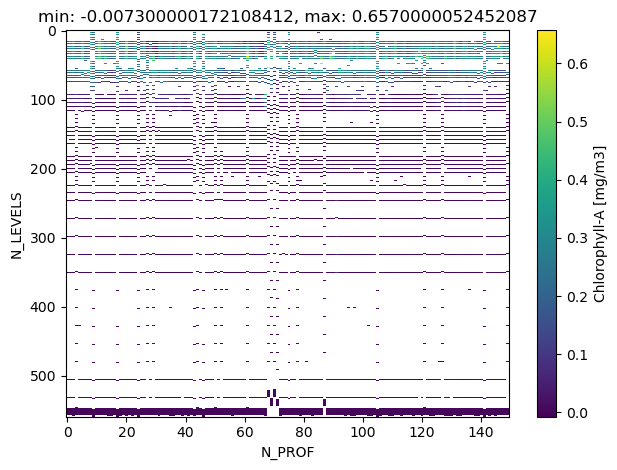

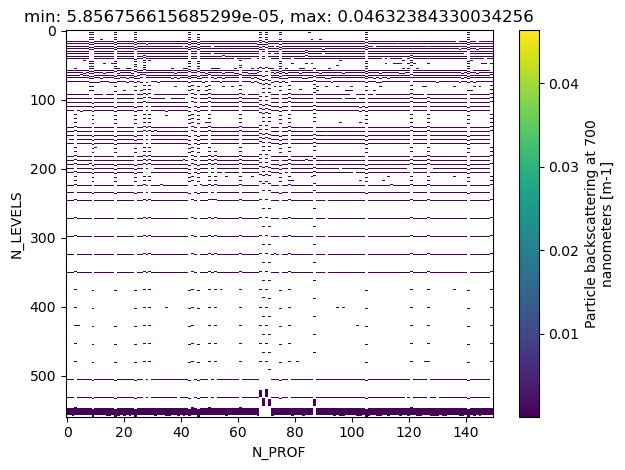

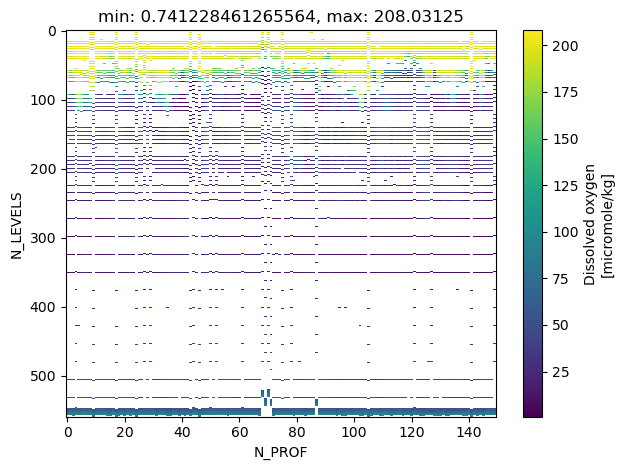

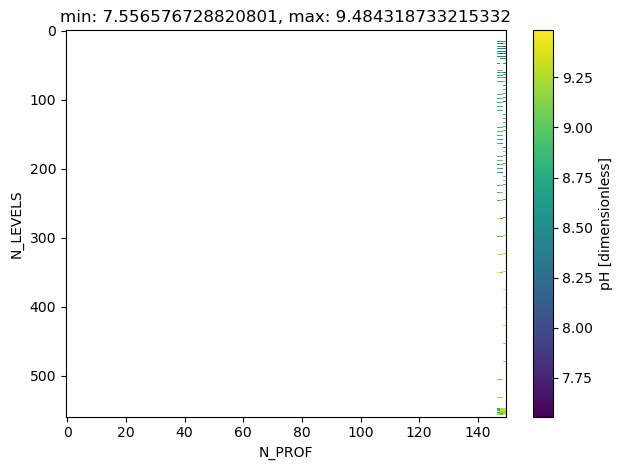

In [98]:
wmoid = 5906475
in_file = f"{wmoid}/{wmoid}_Sprof.nc"
ds = xr.open_dataset(in_file) 

time_and_dt(ds)

plot_raw(ds)

### Exercise 3: 

NO DATA for DOWNWELLING_PAR_ADJUSTED


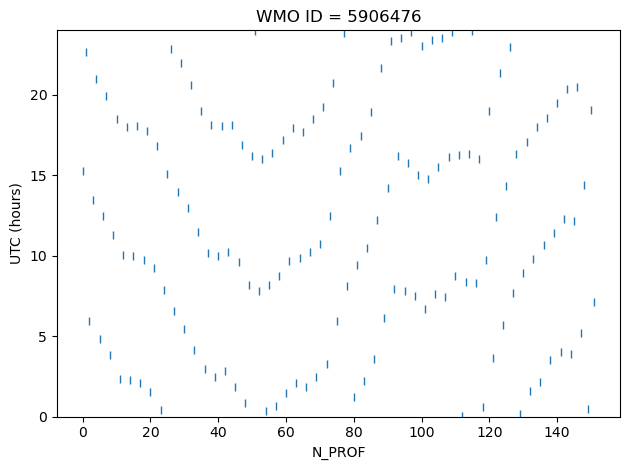

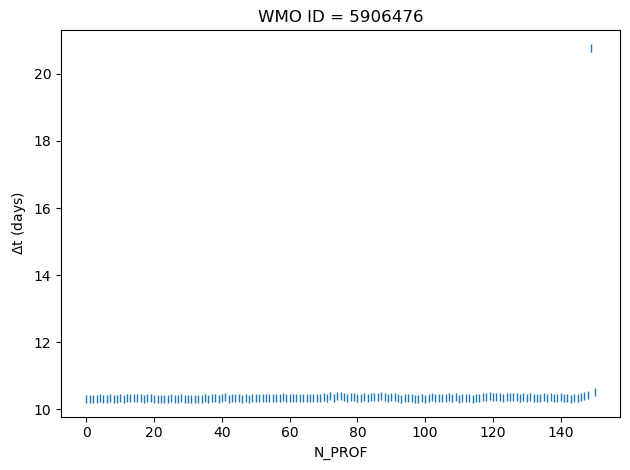

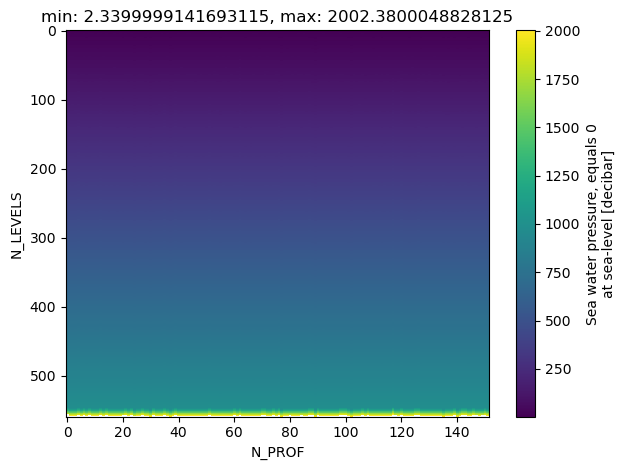

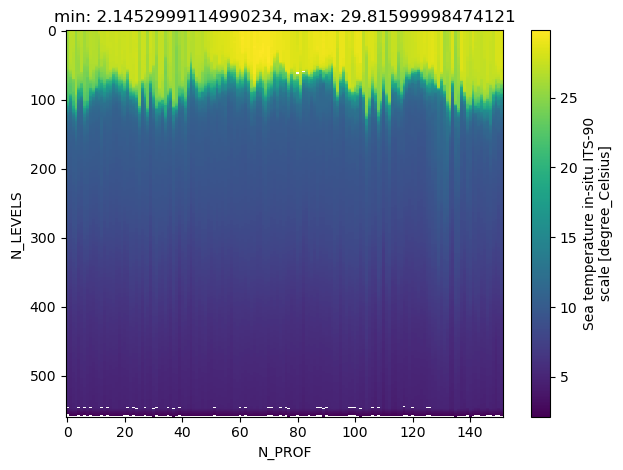

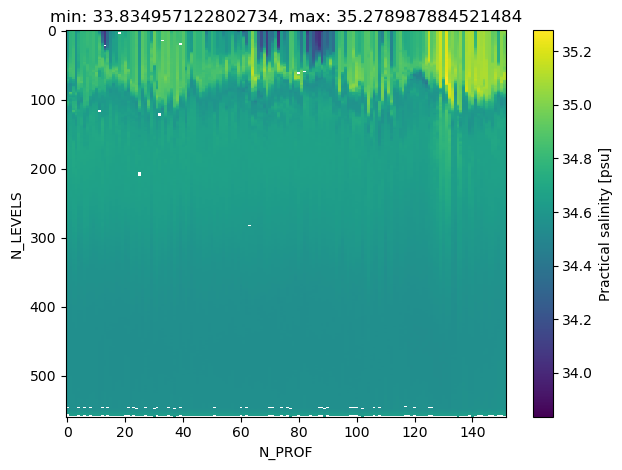

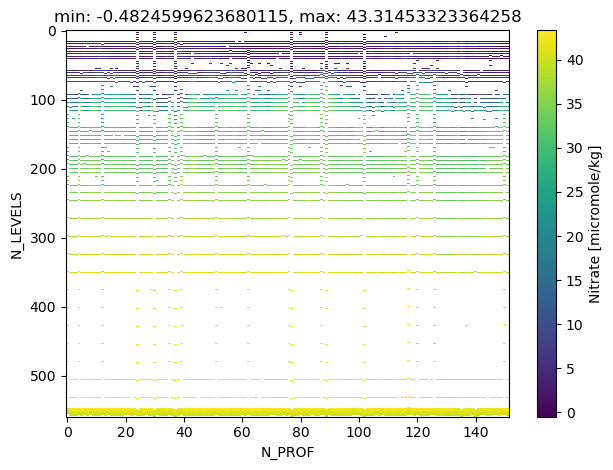

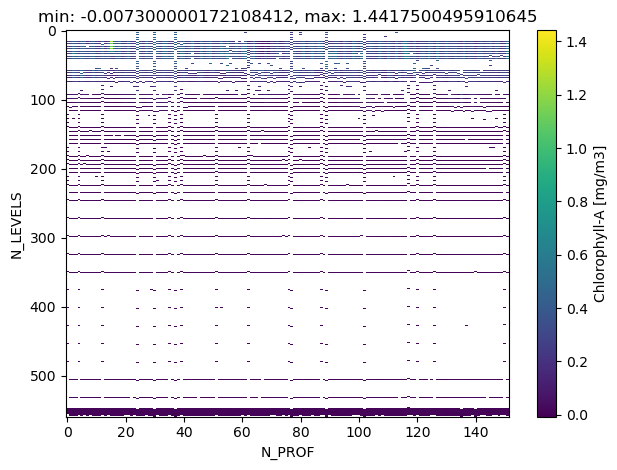

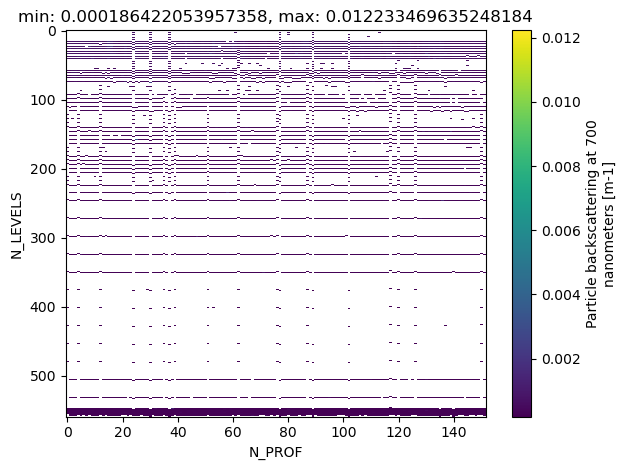

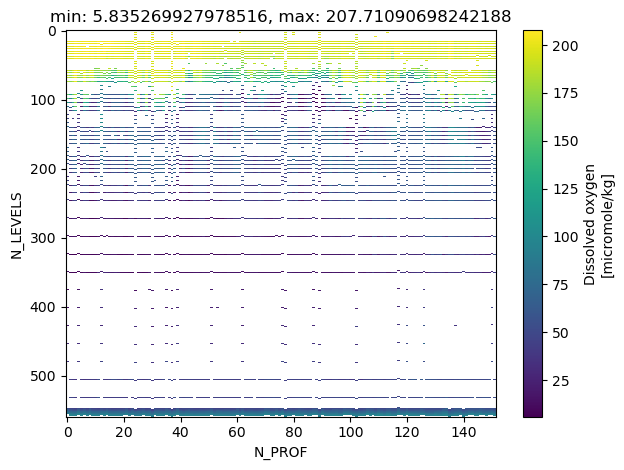

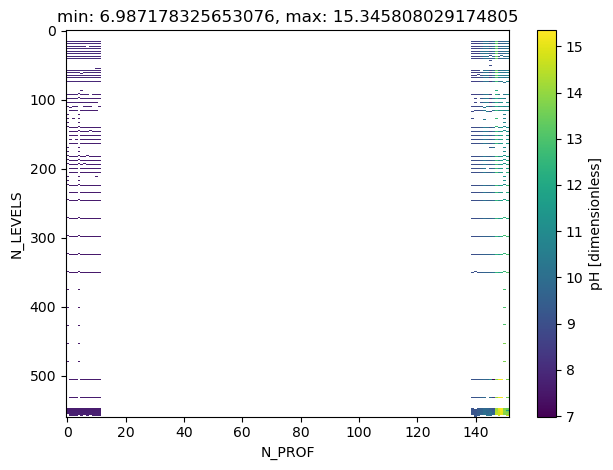

In [99]:
wmoid = 5906476
in_file = f"{wmoid}/{wmoid}_Sprof.nc"
ds = xr.open_dataset(in_file) 

time_and_dt(ds)

plot_raw(ds)


---

This is the end of the lesson. If you are using **Binder**, don't forget to dowload the files created in this lesson before you lose connection!

Well done 🎉 Take a break 💤, have another cup ☕, and move to the next lesson ✍️ when you are ready 💪

While your memory is fresh, please feel free to provide your user experience on this lesson by visiting [this link](https://forms.gle/oAGmz5RTW4Pp46bt7). Thanks!